# 03 — Funnel Analysis

## Context
The primary question is whether the new UX increases **completion rate** — reaching the `confirm` step. But a completion rate is the output of a 5-step funnel. Understanding *where* users drop off is as valuable as the aggregate number: it tells us whether the new UX helps uniformly across the journey, or only at specific steps.

### Funnel definition
```
start → step_1 → step_2 → step_3 → confirm
```
A client is counted at a step if they reached *at least* that step during the test period. Drop-off at each step = clients who stopped there and didn't proceed further.

### Unit reminder
All counts and rates are at `client_id` level. Each client is counted once per step — not once per visit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'Test': '#2563EB', 'Control': '#94A3B8'}
STEP_ORDER = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

df = pd.read_csv('../output/df_analysis_client_level.csv')
df_web = pd.read_csv('../output/df_web_clean.csv')

print(f'Clients: {df.shape[0]:,}')
print(f'Web events: {df_web.shape[0]:,}')

Clients: 70,609
Web events: 553,417


## 1. Build Step-Level Funnel (Client Level)

In [2]:
step_rank = {step: i for i, step in enumerate(STEP_ORDER)}

# For each client, determine which steps they reached
# A client 'reached' step X if their max_step_rank >= rank of X
df_web['step_rank'] = df_web['process_step'].map(step_rank)

# Join experiment group to web data
exp_map = df[['client_id', 'Variation']].drop_duplicates()
df_web_exp = df_web.merge(exp_map, on='client_id', how='inner')

# Max step per client per group
client_max_step = (
    df_web_exp.groupby(['client_id', 'Variation'])['step_rank']
    .max()
    .reset_index()
    .rename(columns={'step_rank': 'max_step_rank'})
)

# Count clients who reached each step (max_step_rank >= step rank)
funnel_records = []
for group in ['Test', 'Control']:
    grp = client_max_step[client_max_step['Variation'] == group]
    total_clients_in_group = df[df['Variation'] == group].shape[0]
    for step, rank in step_rank.items():
        reached = (grp['max_step_rank'] >= rank).sum()
        funnel_records.append({
            'Variation': group,
            'step': step,
            'step_rank': rank,
            'clients_reached': reached,
            'pct_of_group': reached / total_clients_in_group
        })

df_funnel = pd.DataFrame(funnel_records).sort_values(['Variation', 'step_rank'])
display(df_funnel.pivot(index='step', columns='Variation', values=['clients_reached', 'pct_of_group']))

clients_reached          pct_of_group          
Variation         Control     Test      Control      Test
step                                                     
confirm           15262.0  18518.0     0.648564  0.686666
start             23366.0  26822.0     0.992946  0.994586
step_1            20077.0  24361.0     0.853179  0.903330
step_2            18620.0  22378.0     0.791263  0.829798
step_3            17356.0  20966.0     0.737549  0.777440

## 2. Funnel Chart

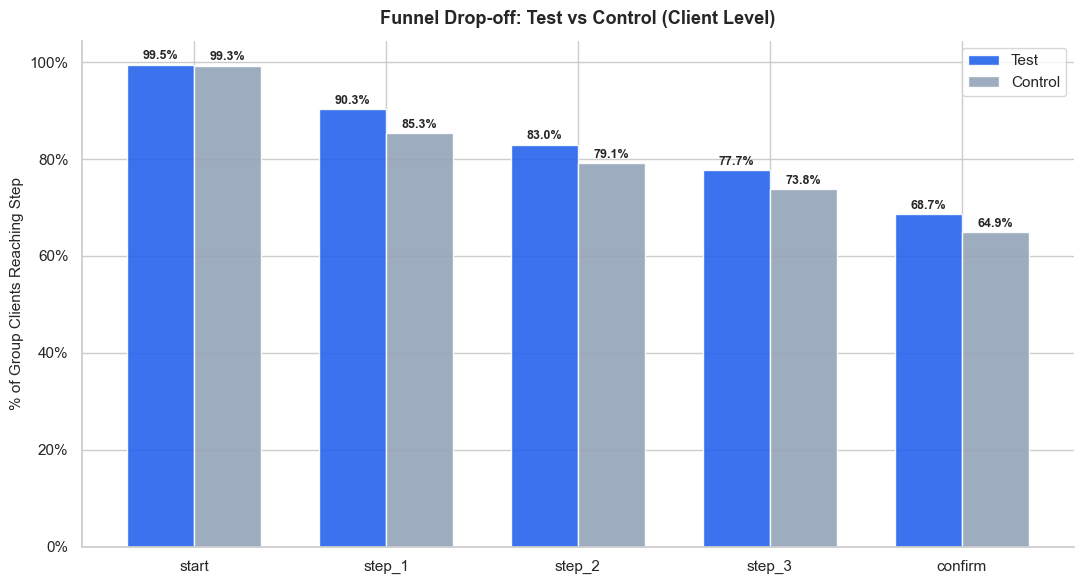

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(len(STEP_ORDER))
width = 0.35

for i, group in enumerate(['Test', 'Control']):
    grp_data = df_funnel[df_funnel['Variation'] == group].sort_values('step_rank')
    offset = (i - 0.5) * width
    bars = ax.bar(
        x + offset,
        grp_data['pct_of_group'].values,
        width=width,
        color=COLORS[group],
        label=group,
        edgecolor='white',
        alpha=0.9
    )
    for bar, pct in zip(bars, grp_data['pct_of_group'].values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{pct:.1%}',
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(STEP_ORDER, fontsize=11)
ax.set_ylabel('% of Group Clients Reaching Step', fontsize=11)
ax.set_title('Funnel Drop-off: Test vs Control (Client Level)', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('../output/funnel_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Step-to-Step Drop-off Rates

In [4]:
dropoff_records = []
for group in ['Test', 'Control']:
    grp = df_funnel[df_funnel['Variation'] == group].sort_values('step_rank').reset_index(drop=True)
    for i in range(1, len(grp)):
        prev_step = grp.loc[i-1, 'step']
        curr_step = grp.loc[i, 'step']
        prev_count = grp.loc[i-1, 'clients_reached']
        curr_count = grp.loc[i, 'clients_reached']
        retention = curr_count / prev_count if prev_count > 0 else 0
        dropoff_records.append({
            'Variation': group,
            'Transition': f'{prev_step} → {curr_step}',
            'Clients In': prev_count,
            'Clients Out': curr_count,
            'Retention Rate': retention,
            'Drop-off Rate': 1 - retention
        })

df_dropoff = pd.DataFrame(dropoff_records)
display(df_dropoff.set_index(['Transition', 'Variation']).round(4))

,,Clients In,Clients Out,Retention Rate,Drop-off Rate
Transition,Variation,,,,
start → step_1,Test,26822,24361,0.9082,0.0918
step_1 → step_2,Test,24361,22378,0.9186,0.0814
step_2 → step_3,Test,22378,20966,0.9369,0.0631
step_3 → confirm,Test,20966,18518,0.8832,0.1168
start → step_1,Control,23366,20077,0.8592,0.1408
step_1 → step_2,Control,20077,18620,0.9274,0.0726
step_2 → step_3,Control,18620,17356,0.9321,0.0679
step_3 → confirm,Control,17356,15262,0.8794,0.1206


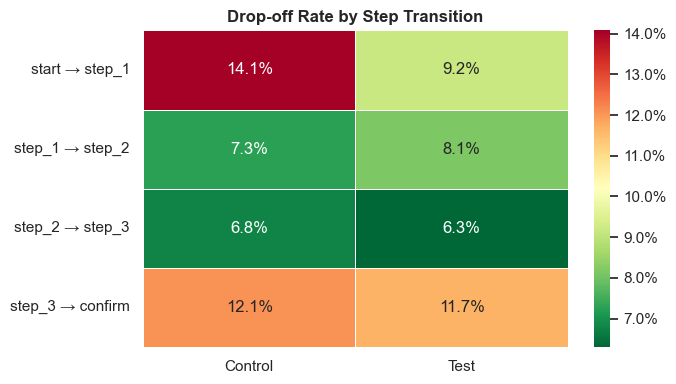

In [5]:
# Heatmap of drop-off rates by step and group
pivot_dropoff = df_dropoff.pivot(index='Transition', columns='Variation', values='Drop-off Rate')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_dropoff,
    annot=True, fmt='.1%',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'format': mtick.PercentFormatter(xmax=1)}
)
ax.set_title('Drop-off Rate by Step Transition', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../output/dropoff_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Completion Rate Summary

In [6]:
completion = df.groupby('Variation')['completed'].agg(['sum', 'count', 'mean'])
completion.columns = ['Completions', 'Total Clients', 'Completion Rate']
completion['Completion Rate %'] = completion['Completion Rate'].map('{:.2%}'.format)

test_rate = completion.loc['Test', 'Completion Rate']
control_rate = completion.loc['Control', 'Completion Rate']
abs_lift = test_rate - control_rate
rel_lift = abs_lift / control_rate

print('=== Completion Rate Summary ===')
display(completion[['Completions', 'Total Clients', 'Completion Rate %']])
print(f'\nAbsolute lift:  {abs_lift:+.2%}')
print(f'Relative lift:  {rel_lift:+.2%}')

=== Completion Rate Summary ===


,Completions,Total Clients,Completion Rate %
Variation,,,
Control,15262,23532,64.86%
Test,18518,26968,68.67%



Absolute lift:  +3.81%
Relative lift:  +5.87%


## Summary

| Step | Test | Control | Drop-off Difference |
|---|---|---|---|
| start → step_1 | 9.2% drop-off | 14.1% drop-off | ✅ −4.9 pp (Test better) |
| step_1 → step_2 | 8.1% drop-off | 7.3% drop-off | ⚠️ +0.8 pp (Control better) |
| step_2 → step_3 | 6.3% drop-off | 6.8% drop-off | ✅ −0.5 pp (Test better) |
| step_3 → confirm | 11.7% drop-off | 12.1% drop-off | ✅ −0.4 pp (Test better) |
| **Overall completion** | **68.67%** | **64.86%** | **+3.81 pp / +5.87% relative lift** |

The largest difference between groups is at the very first transition — `start → step_1`. The new UX reduced early drop-off by 4.9 pp, suggesting the redesign most significantly improved the initial experience of the flow. Gains at later steps are smaller but consistently favour the Test group, with the exception of `step_1 → step_2` where Control marginally outperforms. Statistical significance of the overall lift is confirmed in notebook 04.
